#Building and Understanding the Data Pipeline

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

##Creating the Training Dataset using Tensorflow

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/cifake/train',
    validation_split=0.1,
    subset='training',
    seed=1,
    image_size=(32, 32),
    batch_size=64,
    label_mode='binary'
)

Found 100000 files belonging to 2 classes.
Using 90000 files for training.


In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/cifake/train',
    validation_split=0.1,
    subset='validation',
    seed=1,
    image_size=(32, 32),
    batch_size=64,
    label_mode='binary'
)

Found 100000 files belonging to 2 classes.
Using 10000 files for validation.


###Observation:
--> Diving our training Data inot train+val because we want to monitor our train data without including the test data.  
--> We can change the weights and also keep on monitoring the changes with its results at the same time.

--> Also, this helps us decide things like whether we're overfitting and which model/checkpoint is better by analyziing every epoch.

##Creating the Test Dataset

In [11]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/cifake/test',
    image_size=(32, 32),
    batch_size=64,
    label_mode='binary',
    shuffle=False
)

Found 20000 files belonging to 2 classes.


###
--> We are doing shuffle=False because we don't want the order of the test images to change randomly.

In [12]:
# Class mapping:
# FAKE = 0 ; REAL = 1
print("Class names:", train_ds.class_names)

Class names: ['FAKE', 'REAL']


##Prefetch
--> Making sure that the data is prepared for the GPU

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

#Baseline CNN From Scratch

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

##Explanation:
--> Every image provided to the model is in the form of 32x32 RGB.  
-->Rescaling the image from 0-255 into 0-1 to make it easier for the neural network.  
-->CNN uses a special method called convolution for the model to find complex patterns, shape, edges, etc. Every layer understands something new and useful.  
--> ReLU activation function helps the CNN to understand complex patterns.  
--> By using MaxPooling we ensure that the most important information is being forwarded to the next layer.  
-->After all this the feature map is converted into a list of numbers which the model could understand.  
--> At the end we use sigmoid function to get the output in the range of 0 and 1.


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,209 (1.70 MB)

 Trainable params: 446,209 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

##Compiling the Model

Basically telling keras the exact way to calculate the loss and update weights.



In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

##Training the CNN

###Creating the Earlystopping and ModelCheckpoint

we do early stopping so that if the model stops getting better after a certain epoch it can stop the training.

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/best_scratch_cnn.keras',
    monitor='val_loss',
    save_best_only=True
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8400 - loss: 0.3582 - precision: 0.8296 - recall: 0.8561 - val_accuracy: 0.8946 - val_loss: 0.2746 - val_precision: 0.9242 - val_recall: 0.8584
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8959 - loss: 0.2557 - precision: 0.8892 - recall: 0.9047 - val_accuracy: 0.9065 - val_loss: 0.2358 - val_precision: 0.9489 - val_recall: 0.8582
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9179 - loss: 0.2057 - precision: 0.9142 - recall: 0.9225 - val_accuracy: 0.9286 - val_loss: 0.1830 - val_precision: 0.9327 - val_recall: 0.9230
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9277 - loss: 0.1816 - precision: 0.9249 - recall: 0.9310 - val_accuracy: 0.9230 - val_loss: 0.2016 - val_precision: 0.9518 - val_recall: 0.8902
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9343 - loss: 0.1668 - precision: 0.9317 - recall: 0.9375 - val_accuracy: 0

##Visualizing the Results from the Baseline Model

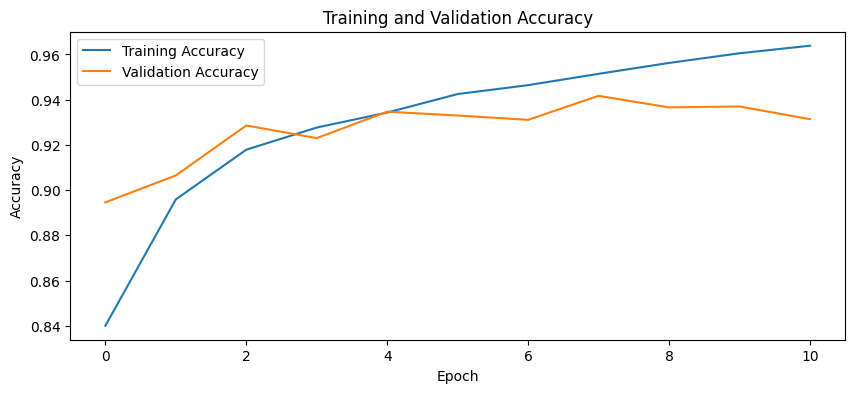

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

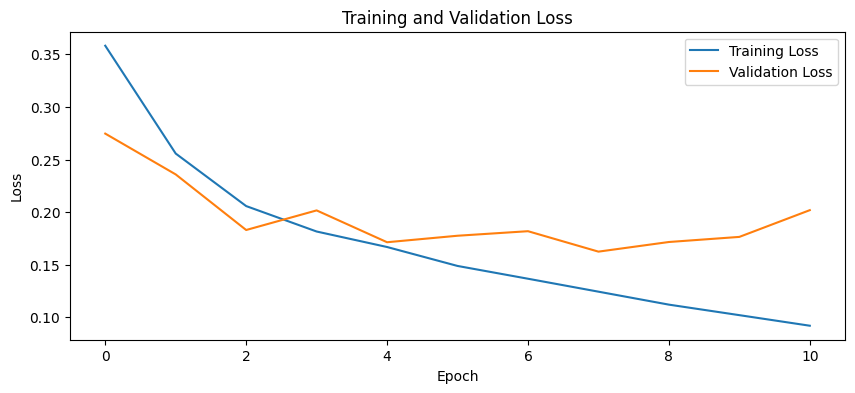

In [20]:
plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

#Transfer Learning with EfficientNetB0

In [21]:
import tensorflow as tf

train_ds_96 = tf.keras.utils.image_dataset_from_directory(
    '/content/cifake/train',
    validation_split=0.1,
    subset='training',
    seed=1,
    image_size=(96, 96),
    batch_size=64,
    label_mode='binary'
)

val_ds_96 = tf.keras.utils.image_dataset_from_directory(
    '/content/cifake/train',
    validation_split=0.1,
    subset='validation',
    seed=1,
    image_size=(96, 96),
    batch_size=64,
    label_mode='binary'
)

test_ds_96 = tf.keras.utils.image_dataset_from_directory(
    '/content/cifake/test',
    image_size=(96, 96),
    batch_size=64,
    label_mode='binary',
    shuffle=False
)

Found 100000 files belonging to 2 classes.
Using 90000 files for training.
Found 100000 files belonging to 2 classes.
Using 10000 files for validation.
Found 20000 files belonging to 2 classes.


##Prefetch

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_96 = train_ds_96.prefetch(buffer_size=AUTOTUNE)
val_ds_96 = val_ds_96.prefetch(buffer_size=AUTOTUNE)
test_ds_96 = test_ds_96.prefetch(buffer_size=AUTOTUNE)

##Loading EfficientNetB0

In [23]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Observation:
--> We are using [weights="imagenet"] becuse we don't want our model to start from random weights instead load the weights learned from ImageNet.  
--> [include_top=False]  is important to make sure we don't use ImageNet's original set of classes

In [24]:
base_model.trainable = False

In [25]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(96, 96, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

transfer_model = Model(inputs, outputs)

##Compiling the Transfer Model

In [26]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [27]:
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

##Creating the Callbacks

In [33]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/best_efficientnet_head.keras',
    monitor='val_loss',
    save_best_only=True
)

###Observations:
--> We know that EfficientNetB0 already has its own information from imagenet so we can use that knowledge in our own model.  
--> We are making sure that our model takes useful info from EfficientNetB0.

In [34]:
history_head = transfer_model.fit(
    train_ds_96,
    validation_data=val_ds_96,
    epochs=15,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9387 - loss: 0.1551 - precision_1: 0.9382 - recall_1: 0.9395 - val_accuracy: 0.9351 - val_loss: 0.1658 - val_precision_1: 0.9341 - val_recall_1: 0.9355
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.9403 - loss: 0.1496 - precision_1: 0.9399 - recall_1: 0.9408 - val_accuracy: 0.9344 - val_loss: 0.1685 - val_precision_1: 0.9330 - val_recall_1: 0.9353
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9406 - loss: 0.1483 - precision_1: 0.9400 - recall_1: 0.9413 - val_accuracy: 0.9389 - val_loss: 0.1633 - val_precision_1: 0.9422 - val_recall_1: 0.9344
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.9426 - loss: 0.1431 - precision_1: 0.9427 - recall_1: 0.9424 - val_accuracy: 0.9345 - val_loss: 0.1675 - val_precision_1: 0.9348 - val_recall_1: 0.9334
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.9449 - loss: 0.1383 - precision_1: 0.9445 

In [35]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [36]:
trainable_layers = 0
total_layers = len(base_model.layers)

for layer in base_model.layers:
    if layer.trainable:
        trainable_layers += 1

print("Total EfficientNet layers:", total_layers)
print("Trainable EfficientNet layers:", trainable_layers)

Total EfficientNet layers: 238
Trainable EfficientNet layers: 30


##Recompiling the Model

In [37]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

##Fine Tuning the Model

In [38]:
fine_tune_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

fine_tune_checkpoint = ModelCheckpoint(
    '/content/best_efficientnet.keras',
    monitor='val_loss',
    save_best_only=True
)

In [39]:
history_fine = transfer_model.fit(
    train_ds_96,
    validation_data=val_ds_96,
    epochs=10,
    callbacks=[fine_tune_early_stopping, fine_tune_checkpoint]
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 94s 47ms/step - accuracy: 0.8723 - loss: 0.5273 - precision_2: 0.8841 - recall_2: 0.8570 - val_accuracy: 0.9121 - val_loss: 0.3167 - val_precision_2: 0.9125 - val_recall_2: 0.9105
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.8999 - loss: 0.3734 - precision_2: 0.9023 - recall_2: 0.8972 - val_accuracy: 0.9232 - val_loss: 0.2674 - val_precision_2: 0.9250 - val_recall_2: 0.9202
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.9128 - loss: 0.2993 - precision_2: 0.9141 - recall_2: 0.9113 - val_accuracy: 0.9290 - val_loss: 0.2389 - val_precision_2: 0.9288 - val_recall_2: 0.9284
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.9211 - loss: 0.2669 - precision_2: 0.9222 - recall_2: 0.9199 - val_accuracy: 0.9333 - val_loss: 0.2192 - val_precision_2: 0.9335 - val_recall_2: 0.9322
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.9280 - loss: 0.2299 - precision_2: 0.9289 

In [48]:
transfer_model.save('/content/efficientnet_model.keras')

#Evaluation and Testing

##Testing of CNN

In [40]:
scratch_probs = model.predict(test_ds)

scratch_probs = scratch_probs.flatten()

print("Number of scratch predictions:", len(scratch_probs))
print("First 10 predictions:", scratch_probs[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Number of scratch predictions: 20000
First 10 predictions: [1.4186381e-07 5.6098554e-05 1.8626857e-04 3.3647329e-06 9.1262418e-04
 4.4990299e-04 5.7146983e-05 1.4896883e-08 2.5355536e-03 1.6415360e-03]


##Testing of EfficientNet

In [41]:
efficientnet_probs = transfer_model.predict(test_ds_96)

efficientnet_probs = efficientnet_probs.flatten()

print("Number of EfficientNet predictions:", len(efficientnet_probs))
print("First 10 predictions:", efficientnet_probs[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step
Number of EfficientNet predictions: 20000
First 10 predictions: [2.2739015e-07 7.6853501e-04 4.4288788e-02 1.7633192e-11 2.1213697e-05
 1.2422181e-03 1.5255649e-12 6.9258233e-15 4.4551540e-02 1.1221729e-02]


In [44]:
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true).astype(int)

In [45]:
scratch_pred = (scratch_probs >= 0.5).astype(int)
efficientnet_pred = (efficientnet_probs >= 0.5).astype(int)

##Classification Report

In [46]:
from sklearn.metrics import classification_report

print("Scratch CNN")
print(classification_report(
    y_true,
    scratch_pred,
    target_names=['FAKE', 'REAL']
))

print("EfficientNetB0")
print(classification_report(
    y_true,
    efficientnet_pred,
    target_names=['FAKE', 'REAL']
))

Scratch CNN
              precision    recall  f1-score   support

        FAKE       0.94      0.94      0.94     10000
        REAL       0.94      0.94      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000

EfficientNetB0
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95     10000
        REAL       0.95      0.94      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



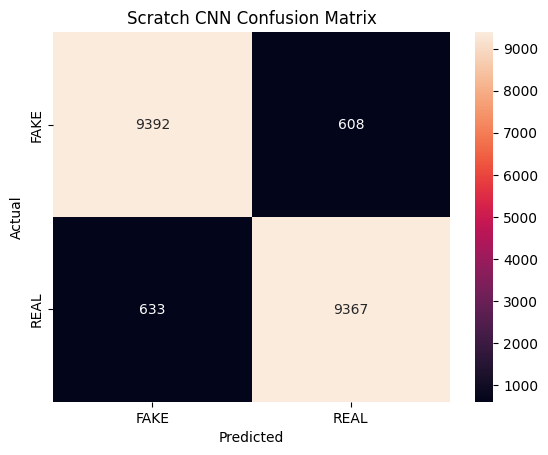

In [49]:
from google.colab import files

files.download("/content/efficientnet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>